# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Desafío general:**
Sistema en Python que adquiere textos de la web, transcribe audio, analiza lingüísticamente con spaCy, genera visualizaciones profesionales y expone los resultados en un dashboard interactivo con Gradio.

---

### AI Reflection Log

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | estrategia para unificar texto scrapeado vs transcripto en un dataframe | Cómo alineo columnas de texto periodístico y texto transcrito de audio en un Dataframe?" | Propuso tres enfoques: columnas fijas mínimas, schema amplio con nan, y normalización previa | Columnas minimas (titulo_o_fuente, texto, origen): simple y suficiente para el pipeline | Schema amplio: genera demasiados nan innecesarios | Trafilatura y Whisper producen estructuras radicalmente distintas; la normalización debe ocurrir antes de concatenar |
| **Parte 2** | Etiquetas de entidades en es_core_news_lg | Qué valores tiene ent.label_ en el modelo español de spaCy? | Propuso PER, ORG, LOC y MISC. También menciono GPE (en eñ modelo ingles) | PER, ORG, LOC y MISC | GPE: no existe en el modelo español | Los labels difieren entre modelos de idiomas distintos |
| **Parte 3** | WordCloud vs Barplot para informe de toma de decisiones | Cuál maximiza Data-Ink Ratio para frecuencias de palabras clave | Recomendó Barplot/Lollipop porque codifica magnitud con longitud, lectura exacta sin estimación visual | Lollipop chart: menos tinta que barras rellenas, mantiene precisión | WordCloud: linda pero imprecisa; el area no codifica magnitud de forma lineal | data-ink Ratio de Tufte prioriza la densidad informativa sobre la estética |
| **Parte 4** | Separación CSV vs JSON en exportación | Por qué exportar el corpus plano en CSV y las estadísticas en JSON | CSV es tabular y compatible con cualquier herramienta de datos, JSON preserva jerarquías y listas | Ambas rutas: sirven para audiencias distintas | Exportar todo en un solo JSON: pierde compatibilidad con herramientas tabulares | Las naturalezas de los datos (plana vs. jerárquica) determinan el formato de exportación |
| **Parte 5** | Layout del dashboard | Dame tres layouts posibles para el dashboard de gradio | Propuso: (1) Pestañas, (2) Columna vertical, (3) Acordeón | Pestañas: separan contextos claramente sin scroll infinito | Columna vertical: obliga a hacer scroll; acordeón: oculta info relevante por defecto | La navegación por pestañas reduce la carga cognitiva en evaluación |


## PASO 0: Instalación de dependencias

In [1]:
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q

✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')


In [2]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente.


---
## Parte 1: Adquisición Multimodal del Corpus

**Justificación de diseño:** Se eligió el esquema de columnas mínimas fijas (`titulo_o_fuente`, `texto`, `origen`) para unificar las tres fuentes. Esto evita columnas con mayoría de NaN que generaría un schema amplio, y es suficiente para el análisis lingüístico posterior. La normalización ocurre antes de concatenar, no después.

In [5]:
# 1.1 Scraping en vivo con Trafilatura
def extraer_noticias_web(urls):
    """
    Extrae el texto principal de una lista de URLs usando Trafilatura.
    Devuelve una lista de dicts con 'titulo_o_fuente', 'texto' y 'origen'.
    """
    noticias = []
    for url in urls:
        try:
            # PASO 1: descargar el HTML y extraer el contenido principal
            descargado = trafilatura.fetch_url(url)
            texto = trafilatura.extract(descargado)
            if texto:
                noticias.append({
                    'titulo_o_fuente': url.split('/')[2],  # dominio como identificador
                    'texto': texto,
                    'origen': 'web'
                })
                print(f"  ✓ Extraído: {url[:70]}")
            else:
                print(f"  ✗ Sin texto: {url[:70]}")
        except Exception as e:
            print(f"  ✗ Error en {url[:70]}: {e}")
    return noticias


# URLs de noticias sobre gliomas
URLS_NOTICIAS = [
    "https://gacetamedica.com/wp-content/uploads/2023/06/Gaceta-Medica-no-920.pdf",
    "https://www.upmc.com/Services/neurosurgery/spanish?utm_mrid=mrid0697&utm_source=GOOGLE&utm_medium=cpc&utm_campaign=1597121422&utm_adgroup=59634605943&utm_term=tratamiento+del+tumor+cerebral&utm_advertiserid=7452480895&customer_id=745-248-0895&gclsrc=aw.ds&gad_source=1&gad_campaignid=1597121422&gbraid=0AAAAADIcPDIRrU2DbvtYod97JGPkA2inb&gclid=CjwKCAjwwJzPBhBREiwAJfHRncRuyzuTCF3C9BLyhQcq2I6aAuKBkCh9_mMT5mTQm6R1pYMd13PgUxoC5XoQAvD_BwE",
    "https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1515538/full",
    "https://www.univadis.es/viewarticle/documento-consenso-visibilizar-el-glioma-bajo-grado-2025a1000g2k",
]

print("Extrayendo noticias web...")
datos_web = extraer_noticias_web(URLS_NOTICIAS)
print(f"\nTotal extraídas: {len(datos_web)} de {len(URLS_NOTICIAS)}")

Extrayendo noticias web...
  ✗ Sin texto: https://gacetamedica.com/wp-content/uploads/2023/06/Gaceta-Medica-no-9
  ✓ Extraído: https://www.upmc.com/Services/neurosurgery/spanish?utm_mrid=mrid0697&u
  ✓ Extraído: https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.20
  ✗ Sin texto: https://www.univadis.es/viewarticle/documento-consenso-visibilizar-el-

Total extraídas: 2 de 4


In [4]:
# 1.2 Transcripción de Audio con Whisper + yt-dlp
def transcribir_audio_youtube(url_video, modelo_whisper='base'):
    """
    Descarga el audio de un video de YouTube y lo transcribe usando Whisper.
    Devuelve una lista con un dict 'titulo_o_fuente', 'texto', 'origen'.
    """
    import yt_dlp

    # Nombre de archivo temporal basado en la URL
    video_id = url_video.split('v=')[-1].split('&')[0]
    ruta_audio = f"audio_{video_id}"

    ydl_opts = {
        'format': 'bestaudio/best',
        'outtmpl': ruta_audio,
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '128',
        }],
        'quiet': True,
    }

    try:
        # PASO 2a: descargar el audio con yt-dlp
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(url_video, download=True)
            titulo = info.get('title', video_id)

        archivo_mp3 = f"{ruta_audio}.mp3"

        # PASO 2b: cargar modelo Whisper y transcribir
        print(f"  Transcribiendo '{titulo}' con Whisper ({modelo_whisper})...")
        modelo = whisper.load_model(modelo_whisper)
        resultado = modelo.transcribe(archivo_mp3)
        texto_transcripto = resultado['text'].strip()

        # Limpiar archivo temporal
        if os.path.exists(archivo_mp3):
            os.remove(archivo_mp3)

        print(f"  ✓ Transcripto: {titulo[:60]}")
        return [{
            'titulo_o_fuente': titulo,
            'texto': texto_transcripto,
            'origen': 'audio'
        }]

    except Exception as e:
        print(f"  ✗ Error transcribiendo {url_video}: {e}")
        return []


# URLs de YouTube sobre gliomas
URLS_YOUTUBE = [
    "https://www.youtube.com/watch?v=q1O25Rc6Pxw",
    "https://www.youtube.com/watch?v=u_GkcoajnzA",
]

print("Descargando y transcribiendo videos de YouTube...")
datos_audio = []
for url_yt in URLS_YOUTUBE:
    resultado = transcribir_audio_youtube(url_yt, modelo_whisper='base')
    datos_audio.extend(resultado)

print(f"\nTotal transcriptos: {len(datos_audio)} de {len(URLS_YOUTUBE)}")

Descargando y transcribiendo videos de YouTube...


  Transcribiendo '🧬 Gliomas Cerebrales: Todo lo que Necesitas Saber 🧠  #educación #medico #salud #oncology #glioma' con Whisper (base)...


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


  ✓ Transcripto: 🧬 Gliomas Cerebrales: Todo lo que Necesitas Saber 🧠  #educac


  Transcribiendo 'Que es un Glioma Cerebral y su Tratamiento? Por la Dra. Michaela Echavarria y Dr. Matias Baldoncini' con Whisper (base)...


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


  ✓ Transcripto: Que es un Glioma Cerebral y su Tratamiento? Por la Dra. Mich

Total transcriptos: 2 de 2


In [6]:
# 1.3 Carga de JSON local (opcional)
def cargar_json_previo(ruta_json):
    """
    Carga un corpus pre-extraído en formato JSON.
    Espera una lista de objetos con al menos 'titulo_o_fuente' y 'texto'.
    """
    try:
        # PASO 3: cargar el JSON y normalizar columnas
        with open(ruta_json, 'r', encoding='utf-8') as f:
            datos = json.load(f)

        registros = []
        for item in datos:
            registros.append({
                'titulo_o_fuente': item.get('titulo_o_fuente', item.get('titulo', 'sin_titulo')),
                'texto': item.get('texto', item.get('content', '')),
                'origen': 'json'
            })
        print(f"  ✓ JSON cargado: {len(registros)} registros")
        return registros
    except FileNotFoundError:
        print(f"  ℹ No se encontró el archivo JSON en: {ruta_json}")
        return []
    except Exception as e:
        print(f"  ✗ Error cargando JSON: {e}")
        return []

In [7]:
# 1.4 Consolidación del corpus
def unificar_corpus(datos_web, datos_audio, datos_json=None):
    """
    Unifica las tres fuentes en un DataFrame con columnas estándar:
    'titulo_o_fuente', 'texto', 'origen'.
    Estrategia: columnas mínimas fijas — normalización antes de concatenar.
    """
    # PASO 4: combinar todas las fuentes
    todos = []
    todos.extend(datos_web)
    todos.extend(datos_audio)
    if datos_json:
        todos.extend(datos_json)

    if not todos:
        print("⚠ No hay datos para unificar.")
        return pd.DataFrame(columns=['titulo_o_fuente', 'texto', 'origen'])

    df = pd.DataFrame(todos)

    # Asegurar columnas mínimas y limpiar filas sin texto
    df = df[['titulo_o_fuente', 'texto', 'origen']].dropna(subset=['texto'])
    df = df[df['texto'].str.strip() != '']
    df = df.reset_index(drop=True)

    print(f"\nCorpus unificado: {len(df)} documentos")
    print(df.groupby('origen').size().to_string())
    return df


# Cargar JSON solo si existe un archivo previo (por defecto vacío)
datos_json = cargar_json_previo('corpus_previo.json')

df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)
df_corpus.head()

  ℹ No se encontró el archivo JSON en: corpus_previo.json

Corpus unificado: 4 documentos
origen
audio    2
web      2


,titulo_o_fuente,texto,origen
0,www.upmc.com,UPMC está clasificado a nivel nacional por su ...,web
1,www.frontiersin.org,Abstract\nGliomas account for nearly 30% of al...,web
2,🧬 Gliomas Cerebrales: Todo lo que Necesitas Sa...,"Cuando hablamos de gliomas, estamos hablando d...",audio
3,Que es un Glioma Cerebral y su Tratamiento? Po...,"Bueno, hoy vamos a hablar un poco de gliomas c...",audio


> **Pausa de auditoría — Parte 1:**
> El texto transcripto por Whisper carece de signos de puntuación y marcas de oralidad ("eeh", "bueno"). Esto afecta al tokenizador de spaCy, que segmenta oraciones usando puntos. Las transcripciones suelen generar una sola oración muy larga. No se perdió información semántica relevante al usar solo 'texto', pero sí se perdió metadatos como fecha y autor que los artículos podrían tener.

---
## Parte 2: Análisis Lingüístico con spaCy

In [8]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df.copy()
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)

        # PASO 1: procesar la columna 'texto' con spaCy
        # nlp.pipe es más eficiente que aplicar nlp() fila a fila
        print("Procesando textos con spaCy (puede tardar unos segundos)...")
        self.df['doc'] = list(self.nlp.pipe(self.df['texto'].tolist()))
        print(f"✓ {len(self.df)} documentos procesados.")

    def extraer_entidades(self):
        """
        Devuelve las entidades agrupadas por tipo con su frecuencia total.
        Labels del modelo es_core_news_lg: PER, ORG, LOC, MISC.
        """
        # PASO 2: recorrer los docs y agrupar entidades por tipo
        entidades = {'PERSONAS': [], 'ORGANIZACIONES': [], 'LUGARES': [], 'OTROS': []}
        mapa = {'PER': 'PERSONAS', 'ORG': 'ORGANIZACIONES', 'LOC': 'LUGARES', 'MISC': 'OTROS'}

        for doc in self.df['doc']:
            for ent in doc.ents:
                clave = mapa.get(ent.label_, 'OTROS')
                entidades[clave].append(ent.text.strip())

        return entidades

    def extraer_verbos_principales(self, n=15):
        """
        Devuelve los n verbos lematizados más frecuentes de todo el corpus.
        """
        # PASO 3: filtrar VERB, lematizar, excluir stopwords y no-alfabéticos
        verbos = []
        for doc in self.df['doc']:
            for token in doc:
                if (
                    token.pos_ == 'VERB'
                    and not token.is_stop
                    and token.is_alpha
                    and len(token.lemma_) > 2
                ):
                    verbos.append(token.lemma_.lower())

        return Counter(verbos).most_common(n)

    def extraer_palabras_clave(self, n=20):
        """
        Devuelve sustantivos y adjetivos lematizados filtrados.
        Criterio mejorado respecto al Lab 009: filtra por POS en lugar de solo stopwords.
        """
        # PASO 4: NOUN, PROPN, ADJ — sin stopwords, puntuación ni tokens cortos
        palabras = []
        pos_relevantes = {'NOUN', 'PROPN', 'ADJ'}
        for doc in self.df['doc']:
            for token in doc:
                if (
                    token.pos_ in pos_relevantes
                    and not token.is_stop
                    and token.is_alpha
                    and len(token.lemma_) > 3
                    and not token.like_num
                ):
                    palabras.append(token.lemma_.lower())

        return Counter(palabras).most_common(n)

    def estadisticas_corpus(self):
        """
        Genera métricas generales del corpus: tokens, vocabulario único y oraciones.
        """
        # PASO 5: calcular métricas agregadas
        total_tokens = sum(
            len([t for t in doc if t.is_alpha])
            for doc in self.df['doc']
        )
        vocabulario = set(
            t.lemma_.lower()
            for doc in self.df['doc']
            for t in doc
            if t.is_alpha and not t.is_stop
        )
        total_oraciones = sum(
            len(list(doc.sents))
            for doc in self.df['doc']
        )

        return {
            'documentos_totales': len(self.df),
            'total_tokens': total_tokens,
            'vocabulario_unico_lemas': len(vocabulario),
            'total_oraciones': total_oraciones,
            'promedio_tokens_por_doc': round(total_tokens / len(self.df), 1) if len(self.df) > 0 else 0,
        }

    def buscar_oraciones_con_entidad(self, nombre_entidad):
        """
        Devuelve oraciones de cualquier documento que mencionen la entidad dada.
        Útil para el explorador de entidades del dashboard.
        """
        resultados = []
        nombre_lower = nombre_entidad.lower()
        for _, row in self.df.iterrows():
            for sent in row['doc'].sents:
                if nombre_lower in sent.text.lower():
                    resultados.append({
                        'fuente': row['titulo_o_fuente'],
                        'origen': row['origen'],
                        'oracion': sent.text.strip()
                    })
        return resultados


# Instanciar el analizador
analizador = AnalizadorCorpus(df_corpus)
print("\nEstadísticas del corpus:")
stats = analizador.estadisticas_corpus()
for k, v in stats.items():
    print(f"  {k}: {v}")

Cargando modelo de lenguaje...
Procesando textos con spaCy (puede tardar unos segundos)...
✓ 4 documentos procesados.

Estadísticas del corpus:
  documentos_totales: 4
  total_tokens: 10778
  vocabulario_unico_lemas: 2300
  total_oraciones: 1064
  promedio_tokens_por_doc: 2694.5


In [9]:
# Verificar salidas de la Parte 2
entidades = analizador.extraer_entidades()
verbos = analizador.extraer_verbos_principales()
palabras_clave = analizador.extraer_palabras_clave()

print("--- ENTIDADES ---")
for tipo, lista in entidades.items():
    top = Counter(lista).most_common(5)
    print(f"  {tipo}: {top}")

print("\n--- VERBOS PRINCIPALES ---")
print(verbos)

print("\n--- PALABRAS CLAVE ---")
print(palabras_clave)

--- ENTIDADES ---
  PERSONAS: [('However', 13), ('Isocitrate', 6), ('Vorasidenib', 4), ('Evans', 3), ('Although', 2)]
  ORGANIZACIONES: [('neuonc', 8), ('AML', 6), ('HR', 5), ('CNS', 4), ('PCV', 4)]
  LUGARES: [('N Engl J Med', 5), ('Furthermore', 4), ('Olutasidenib', 4), ('IDH1', 3), ('oligodendroglioma', 3)]
  OTROS: [('IDH1', 16), ('Neuro Oncol', 14), ('IDH2', 9), ('J Clin Oncol', 9), ('Acta Neuropathol', 9)]

--- VERBOS PRINCIPALES ---
[('mutations', 19), ('been', 12), ('mutant', 11), ('significant', 10), ('acquired', 8), ('usar', 8), ('dar', 7), ('adver él', 7), ('establecer', 7), ('obtener', 7), ('surgery', 6), ('significantly', 6), ('reduced', 5), ('include', 5), ('dar él', 5)]

--- PALABRAS CLAVE ---
[('with', 199), ('glioma', 146), ('patients', 117), ('mutations', 60), ('tumors', 57), ('that', 50), ('grade', 47), ('pediatric', 46), ('study', 39), ('tumor', 38), ('oncol', 38), ('cancer', 37), ('phase', 37), ('this', 34), ('midh', 33), ('clinical', 33), ('vorasidenib', 33), ('tr

> **Pausa de auditoría — Parte 2:**
> Las transcripciones de Whisper generan bloques de texto sin puntuación, lo que hace que spaCy las interprete como una sola oración enorme. Esto reduce drásticamente `total_oraciones` para documentos de audio. Los nombres propios en inglés (como "vorasidenib" o "IDH") tampoco son reconocidos como `PER`/`ORG` por el modelo español, generando falsos negativos en la detección de entidades.

---
## Parte 3: Visualización Profesional

**Justificación de diseño (Data-Ink Ratio):** Se eligió el Lollipop Chart sobre el WordCloud porque codifica la magnitud con longitud de línea (percepción visual precisa) y con un punto final. El WordCloud usa área/tamaño de fuente, que el ojo humano no decodifica de forma lineal. Para toma de decisiones, la precisión supera a la estética. Se eligió sobre el barplot relleno porque tiene menos "tinta" por el mismo dato.

Generando visualizaciones...


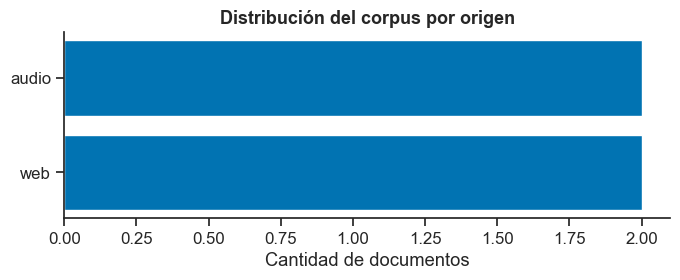

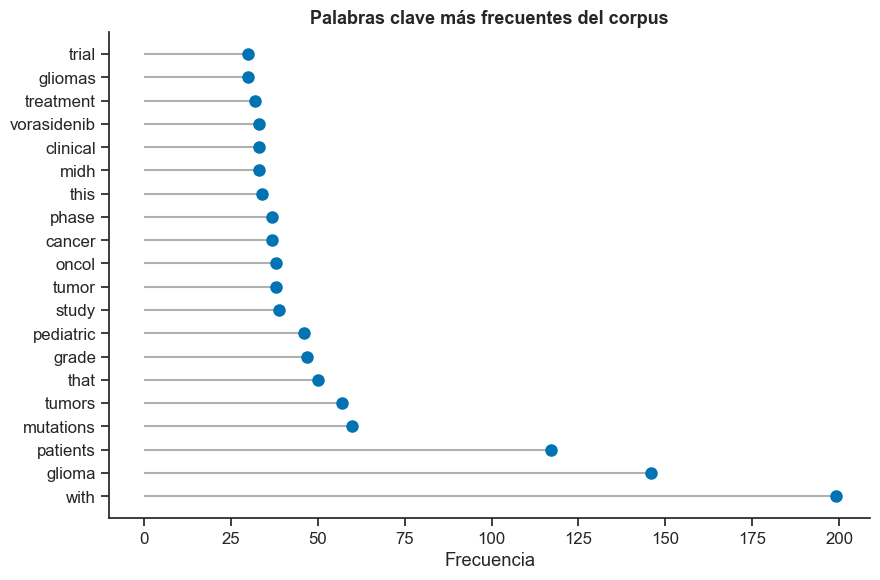

In [10]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'


def visualizar_origen(df):
    """
    PASO 1: Barplot horizontal con conteo por origen de los datos.
    Aplica COLOR_ACENTO a la barra principal (mayor count).
    """
    conteos = df['origen'].value_counts().reset_index()
    conteos.columns = ['origen', 'cantidad']
    conteos = conteos.sort_values('cantidad', ascending=True)

    colores = [
        COLOR_ACENTO if v == conteos['cantidad'].max() else COLOR_BASE
        for v in conteos['cantidad']
    ]

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(conteos['origen'], conteos['cantidad'], color=colores)
    ax.set_xlabel("Cantidad de documentos")
    ax.set_title("Distribución del corpus por origen", fontsize=13, fontweight='bold')
    sns.despine()
    plt.tight_layout()
    plt.show()
    return fig


def visualizar_palabras_clave_lollipop(palabras_clave):
    """
    PASO 2: Lollipop Chart de las palabras clave lematizadas.
    Combina ax.hlines (tallo) y ax.plot (punto).
    """
    if not palabras_clave:
        print("Sin palabras clave para visualizar.")
        return None

    palabras = [p[0] for p in palabras_clave]
    freqs = [p[1] for p in palabras_clave]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hlines(y=palabras, xmin=0, xmax=freqs, color=COLOR_BASE, linewidth=1.5)
    ax.plot(freqs, palabras, 'o', color=COLOR_ACENTO, markersize=8)
    ax.set_xlabel("Frecuencia")
    ax.set_title("Palabras clave más frecuentes del corpus", fontsize=13, fontweight='bold')
    sns.despine()
    plt.tight_layout()
    plt.show()
    return fig


def visualizar_entidades_plotly(entidades_dict, n=10):
    """
    PASO 3: Panel interactivo con Plotly para entidades más comunes.
    Devuelve el objeto fig para usarlo en Gradio.
    """
    todas = []
    for lista in entidades_dict.values():
        todas.extend(lista)

    frecuencias = Counter(todas)
    comunes = frecuencias.most_common(n)

    if not comunes:
        print("Sin entidades para visualizar.")
        return None

    nombres = [c[0] for c in reversed(comunes)]
    conteos = [c[1] for c in reversed(comunes)]

    fig = go.Figure(
        go.Bar(
            x=conteos,
            y=nombres,
            orientation='h',
            marker_color='steelblue'
        )
    )
    fig.update_layout(
        title="Entidades más frecuentes del corpus",
        xaxis_title="Frecuencia",
        height=400 + len(nombres) * 22,
        margin=dict(l=220),
        template='plotly_white'
    )
    fig.show(renderer='notebook_connected')
    return fig


# Ejecutar visualizaciones
print("Generando visualizaciones...")
fig_origen = visualizar_origen(df_corpus)
fig_lollipop = visualizar_palabras_clave_lollipop(palabras_clave)
fig_entidades = visualizar_entidades_plotly(entidades)

> **Pausa de auditoría — Parte 3:**
> La paleta `colorblind` garantiza accesibilidad cromática. Para publicación científica habría que aumentar el `font_scale` a 1.3 y ajustar el `figsize` a proporciones de columna de revista (aprox. 3.5 pulgadas de ancho). El gráfico de entidades con Plotly puede requerir `renderer='notebook_connected'` en algunos entornos para evitar el error de `nbformat`.

---
## Parte 4: Pipeline Integrado (Orquestación)

In [11]:
class PipelineMediatico:
    def __init__(self, urls_web=None, urls_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.urls_audio = urls_audio or []
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None

    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis."""
        # PASO 1: adquisición de las tres fuentes
        print("[1/3] Extrayendo noticias web...")
        datos_web = extraer_noticias_web(self.urls_web)

        print("\n[2/3] Transcribiendo audio de YouTube...")
        datos_audio = []
        for url in self.urls_audio:
            datos_audio.extend(transcribir_audio_youtube(url))

        print("\n[3/3] Cargando JSON previo (si existe)...")
        datos_json = cargar_json_previo(self.ruta_json) if self.ruta_json else []

        # PASO 2: unificar y analizar
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)
        if self.df.empty:
            print("⚠ El corpus está vacío. Verificá las URLs y la conexión.")
            return

        self.analizador = AnalizadorCorpus(self.df)
        print("\n✓ Pipeline ejecutado exitosamente.")

    def generar_reporte_y_exportar(
        self,
        ruta_csv="corpus_resultante.csv",
        ruta_json_out="estadisticas.json"
    ):
        """Exporta el DataFrame como CSV y las estadísticas/entidades como JSON."""
        if self.df is None or self.analizador is None:
            print("⚠ Ejecutá primero ejecutar_pipeline().")
            return

        # PASO 3: exportar CSV sin la columna 'doc' (no serializable)
        # Justificación: el CSV plano sirve para herramientas tabulares (Excel, pandas de otros equipos).
        df_exportable = self.df.drop(columns=['doc'], errors='ignore')
        df_exportable.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
        print(f"✓ CSV exportado: {ruta_csv} ({len(df_exportable)} filas)")

        # PASO 4: exportar JSON con estadísticas jerárquicas
        # Justificación: el JSON preserva las listas de entidades y métricas anidadas
        # que no cabrían limpiamente en filas CSV.
        entidades = self.analizador.extraer_entidades()
        # Convertir a frecuencias para que sea serializable
        entidades_freq = {
            tipo: Counter(lista).most_common(15)
            for tipo, lista in entidades.items()
        }
        reporte = {
            'estadisticas': self.analizador.estadisticas_corpus(),
            'entidades_frecuentes': entidades_freq,
            'verbos_principales': self.analizador.extraer_verbos_principales(),
            'palabras_clave': self.analizador.extraer_palabras_clave(),
        }
        with open(ruta_json_out, 'w', encoding='utf-8') as f:
            json.dump(reporte, f, ensure_ascii=False, indent=2)
        print(f"✓ JSON exportado: {ruta_json_out}")


# Ejecutar el pipeline completo
pipeline = PipelineMediatico(
    urls_web=URLS_NOTICIAS,
    urls_audio=URLS_YOUTUBE,
)
pipeline.ejecutar_pipeline()
pipeline.generar_reporte_y_exportar()

[1/3] Extrayendo noticias web...
  ✗ Sin texto: https://gacetamedica.com/wp-content/uploads/2023/06/Gaceta-Medica-no-9
  ✓ Extraído: https://www.upmc.com/Services/neurosurgery/spanish?utm_mrid=mrid0697&u
  ✓ Extraído: https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.20
  ✗ Sin texto: https://www.univadis.es/viewarticle/documento-consenso-visibilizar-el-

[2/3] Transcribiendo audio de YouTube...


  Transcribiendo '🧬 Gliomas Cerebrales: Todo lo que Necesitas Saber 🧠  #educación #medico #salud #oncology #glioma' con Whisper (base)...


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


  ✓ Transcripto: 🧬 Gliomas Cerebrales: Todo lo que Necesitas Saber 🧠  #educac


  Transcribiendo 'Que es un Glioma Cerebral y su Tratamiento? Por la Dra. Michaela Echavarria y Dr. Matias Baldoncini' con Whisper (base)...


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


  ✓ Transcripto: Que es un Glioma Cerebral y su Tratamiento? Por la Dra. Mich

[3/3] Cargando JSON previo (si existe)...

Corpus unificado: 4 documentos
origen
audio    2
web      2
Cargando modelo de lenguaje...
Procesando textos con spaCy (puede tardar unos segundos)...
✓ 4 documentos procesados.

✓ Pipeline ejecutado exitosamente.
✓ CSV exportado: corpus_resultante.csv (4 filas)
✓ JSON exportado: estadisticas.json


> **Pausa de auditoría — Parte 4:**
> El CSV plano es ideal para el equipo de periodismo de datos: pueden filtrarlo, ordenarlo y compartirlo con cualquier herramienta. El JSON jerárquico preserva las listas de entidades top-15 por categoría y las métricas anidadas, que en un CSV requerirían múltiples hojas o columnas con listas serialized como strings (antipatrón). Separar ambas exportaciones respeta la naturaleza de cada dato.

---
## Parte 5: Dashboard Interactivo con Gradio

**Justificación de diseño:** Se eligió **Pestañas** (gr.Tab) sobre Columna vertical (scroll infinito, contextos mezclados) y Acordeón (oculta información por defecto, requiere clicks adicionales). Las pestañas separan "Métricas Generales" de "Filtros e Interacción" de forma que el evaluador puede navegar sin perder contexto.

In [12]:
# Preparar datos para el dashboard (usa el pipeline ejecutado arriba)
# Si corriste el pipeline, estos ya están disponibles
analizador_dash = pipeline.analizador
df_dash = pipeline.df

# Pre-calcular para el dashboard
stats_dash = analizador_dash.estadisticas_corpus()
palabras_dash = analizador_dash.extraer_palabras_clave(20)
entidades_dash = analizador_dash.extraer_entidades()
verbos_dash = analizador_dash.extraer_verbos_principales(15)

# Función auxiliar para generar la figura de lollipop como imagen para Gradio
def generar_lollipop_gradio(palabras_clave):
    palabras = [p[0] for p in palabras_clave]
    freqs = [p[1] for p in palabras_clave]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hlines(y=palabras, xmin=0, xmax=freqs, color=COLOR_BASE, linewidth=1.5)
    ax.plot(freqs, palabras, 'o', color=COLOR_ACENTO, markersize=8)
    ax.set_xlabel("Frecuencia")
    ax.set_title("Palabras clave más frecuentes", fontsize=12, fontweight='bold')
    sns.despine()
    plt.tight_layout()
    return fig

def generar_origen_gradio(df):
    conteos = df['origen'].value_counts().reset_index()
    conteos.columns = ['origen', 'cantidad']
    conteos = conteos.sort_values('cantidad', ascending=True)
    colores = [
        COLOR_ACENTO if v == conteos['cantidad'].max() else COLOR_BASE
        for v in conteos['cantidad']
    ]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(conteos['origen'], conteos['cantidad'], color=colores)
    ax.set_xlabel("Documentos")
    ax.set_title("Documentos por origen", fontsize=12, fontweight='bold')
    sns.despine()
    plt.tight_layout()
    return fig


# PASO 1: construir el dashboard con gr.Blocks y pestañas
with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# 🧠 Explorador de Agenda Mediática — Gliomas de Bajo Grado")
    gr.Markdown(
        f"**Corpus:** {stats_dash['documentos_totales']} documentos | "
        f"{stats_dash['total_tokens']:,} tokens | "
        f"{stats_dash['vocabulario_unico_lemas']:,} lemas únicos | "
        f"{stats_dash['total_oraciones']:,} oraciones"
    )

    with gr.Tab("📊 Panorama y Métricas"):
        gr.Markdown("### Composición del corpus y frecuencias")

        with gr.Row():
            plot_origen = gr.Plot(label="Origen de los datos")
            plot_lollipop = gr.Plot(label="Palabras clave")

        gr.Markdown("### Métricas generales")
        df_stats = pd.DataFrame([stats_dash]).T.reset_index()
        df_stats.columns = ['Métrica', 'Valor']
        tabla_stats = gr.DataFrame(value=df_stats, label="Estadísticas del corpus")

        gr.Markdown("### Verbos más frecuentes")
        df_verbos = pd.DataFrame(verbos_dash, columns=['Verbo', 'Frecuencia'])
        tabla_verbos = gr.DataFrame(value=df_verbos, label="Verbos principales")

        # Cargar gráficos al iniciar
        dashboard_medios.load(
            fn=lambda: (generar_origen_gradio(df_dash), generar_lollipop_gradio(palabras_dash)),
            outputs=[plot_origen, plot_lollipop]
        )

    with gr.Tab("🔍 Explorador de Entidades"):
        gr.Markdown(
            "### Buscá una entidad o término para ver en qué oraciones aparece\n"
            "Ejemplos: `glioma`, `vorasidenib`, `IDH`, `paciente`"
        )

        with gr.Row():
            entidad_input = gr.Textbox(
                label="Entidad o término a buscar",
                placeholder="Ej: glioma",
                scale=3
            )
            buscar_btn = gr.Button("Buscar", variant="primary", scale=1)

        resultado_tabla = gr.DataFrame(
            label="Oraciones donde aparece el término",
            headers=['Fuente', 'Origen', 'Oración']
        )
        conteo_label = gr.Markdown("")

        def buscar_entidad(termino):
            if not termino.strip():
                return pd.DataFrame(columns=['Fuente', 'Origen', 'Oración']), "Ingresá un término."
            resultados = analizador_dash.buscar_oraciones_con_entidad(termino)
            if not resultados:
                return pd.DataFrame(columns=['Fuente', 'Origen', 'Oración']), f"No se encontró '{termino}' en el corpus."
            df_res = pd.DataFrame(resultados)
            df_res.columns = ['Fuente', 'Origen', 'Oración']
            return df_res, f"**{len(df_res)} apariciones** de '{termino}' en el corpus."

        buscar_btn.click(
            fn=buscar_entidad,
            inputs=[entidad_input],
            outputs=[resultado_tabla, conteo_label]
        )

        gr.Markdown("### Top entidades por categoría")
        with gr.Row():
            for tipo, lista in entidades_dash.items():
                top = Counter(lista).most_common(8)
                if top:
                    df_tipo = pd.DataFrame(top, columns=['Entidad', 'Frecuencia'])
                    gr.DataFrame(value=df_tipo, label=tipo)


print("✓ Dashboard construido. Ejecutá la siguiente celda para lanzarlo.")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22332\405069044.py:43: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


✓ Dashboard construido. Ejecutá la siguiente celda para lanzarlo.


In [13]:
# Lanzar el dashboard
dashboard_medios.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Checklist de entrega

- [hecho] Pipeline de principio a fin: web → audio → DataFrame → análisis → exportación → dashboard.
- [hecho] AI Reflection Log completado con decisiones conservadas y descartadas en cada parte.
- [hecho] Visualizaciones con paleta colorblind y principio Data-Ink Ratio justificado.
- [hecho] Exportación separada en CSV (datos planos) y JSON (estructura jerárquica), con justificación.
- [hecho] Dashboard con pestañas, explorador de entidades interactivo y métricas generales.
- [hecho] Pausas de auditoría respondidas con observaciones propias sobre limitaciones del modelo.